<a href="https://colab.research.google.com/github/liseth182/Finanzas-/blob/main/geometrias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


librerias

In [ ]:
import os
from glob import glob
import numpy as np

In [ ]:
carpeta1 = "/content/drive/MyDrive/estudioparcial_vision /Alpinia Galanga (Rasna)"
carpeta2 = "/content/drive/MyDrive/estudioparcial_vision /Citrus Limon (Lemon)"
carpeta3 = "/content/drive/MyDrive/estudioparcial_vision /Mangifera Indica (Mango)"

carpetas_clases = [carpeta1, carpeta2, carpeta3]
num_classes = len(carpetas_clases)

# Extensiones soportadas
exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.tif","*.tiff")

def listar_imagenes(carpeta):
    rutas = []
    for e in exts:
        rutas += glob(os.path.join(carpeta, e))
    return sorted(rutas)

# Lista de rutas por clase
listas_imagenes = [listar_imagenes(c) for c in carpetas_clases]

# Balancear: usar el mismo número por clase (como tu ejemplo: 30 por clase)
num_images_per_class = min(len(lst) for lst in listas_imagenes)

print("num_classes =", num_classes)
print("num_images_per_class (balanceado) =", num_images_per_class)
for i, lst in enumerate(listas_imagenes):
    print(f"Clase {i}: {len(lst)} imágenes disponibles | Usaremos {num_images_per_class}")

num_classes = 3
num_images_per_class (balanceado) = 50
Clase 0: 50 imágenes disponibles | Usaremos 50
Clase 1: 57 imágenes disponibles | Usaremos 50
Clase 2: 62 imágenes disponibles | Usaremos 50


In [ ]:
import cv2

def imageload_from_path(path, echo=False):
    """
    Carga imagen desde una ruta (Drive) y la devuelve en escala de grises normalizada [0,1].
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = img.astype(np.float32) / 255.0
    if echo:
        print("Loaded:", path, "| shape:", img.shape)
    return img

In [ ]:
def fourierdes_2d(img_gray_01, num_descriptors=16, resize_to=256):
    """
    'Fourier descriptors' para TEXTURA usando Fourier 2D del contenido:
    - resize para que todas tengan el mismo tamaño
    - FFT 2D + shift
    - magnitud en log
    - perfil radial del espectro (lo reduce a un vector 1D)
    - devuelve vector de num_descriptors
    """
    # 1) Asegurar tamaño fijo (importante para comparar FFT)
    img = cv2.resize(img_gray_01, (resize_to, resize_to), interpolation=cv2.INTER_AREA)

    # 2) Fourier 2D
    F = np.fft.fft2(img)
    Fshift = np.fft.fftshift(F)
    mag = np.log1p(np.abs(Fshift)).astype(np.float32)

    # 3) Perfil radial (promedio por radios)
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    r = np.sqrt((X - cx)**2 + (Y - cy)**2).astype(np.int32)

    r_max = r.max()
    sum_r = np.bincount(r.ravel(), weights=mag.ravel(), minlength=r_max+1)
    cnt_r = np.bincount(r.ravel(), minlength=r_max+1)
    radial = sum_r / np.maximum(cnt_r, 1)

    # 4) Reducir a num_descriptors
    idx = np.linspace(0, len(radial)-1, num_descriptors).astype(int)
    desc = radial[idx].astype(np.float32)

    return desc

def normalize_desc(desc):
    """
    Normalización segura: desc / ||desc|| (como tu notebook)
    """
    return desc / (np.linalg.norm(desc) + 1e-8)

In [ ]:
num_descriptors = 16  # igual a tu notebook

X = np.zeros((num_classes * num_images_per_class, num_descriptors), dtype=np.float32)
y = np.zeros((num_classes * num_images_per_class,), dtype=np.int32)

t = 0
for class_idx in range(num_classes):          # for each class
    for image_idx in range(num_images_per_class):  # for each image in the class

        # Load the image (desde Drive)
        path = listas_imagenes[class_idx][image_idx]
        loaded_image = imageload_from_path(path, echo=False)
        if loaded_image is None:
            continue

        # (Opcional) "segmentation": para texturas NO es necesaria.
        # Dejamos la línea para mantener estructura, pero la usamos como 'paso identidad'
        segmented_image = loaded_image  # <- para textura, no segmentamos

        # Feature extraction (Fourier descriptors)
        fourier_descriptors = fourierdes_2d(segmented_image, num_descriptors=num_descriptors, resize_to=256)

        # normalization
        normalized_descriptors = normalize_desc(fourier_descriptors)

        # store
        X[t, :] = normalized_descriptors
        y[t] = class_idx
        t += 1

# Recortar por si alguna imagen falló
X = X[:t, :]
y = y[:t]

print("✅ Listo")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Clases en y:", np.unique(y))

✅ Listo
X shape: (150, 16)
y shape: (150,)
Clases en y: [0 1 2]


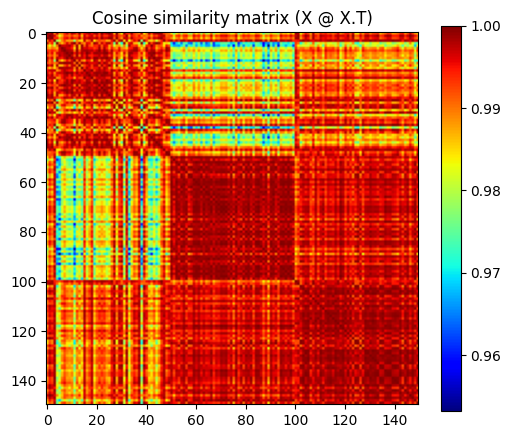

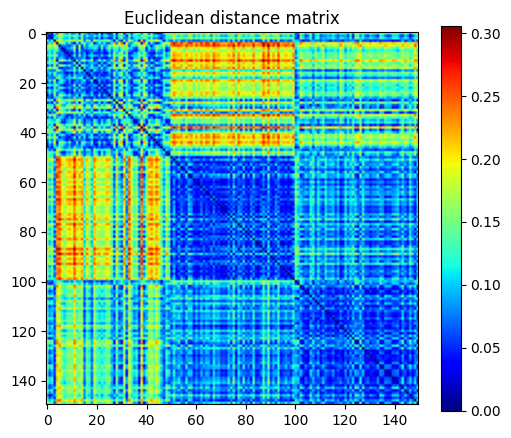

In [ ]:
import matplotlib.pyplot as plt

# Similitud coseno (porque X está normalizado)
similarity_matrix = X @ X.T

plt.figure(figsize=(6,5))
plt.imshow(similarity_matrix, cmap='jet')
plt.title("Cosine similarity matrix (X @ X.T)")
plt.colorbar()
plt.show()

# Si quieres DISTANCIA euclidiana (derivada de similitud por norma 1)
d2 = np.clip(2 - 2*similarity_matrix, 0, None)
distance_matrix = np.sqrt(d2)

plt.figure(figsize=(6,5))
plt.imshow(distance_matrix, cmap='jet')
plt.title("Euclidean distance matrix")
plt.colorbar()
plt.show()

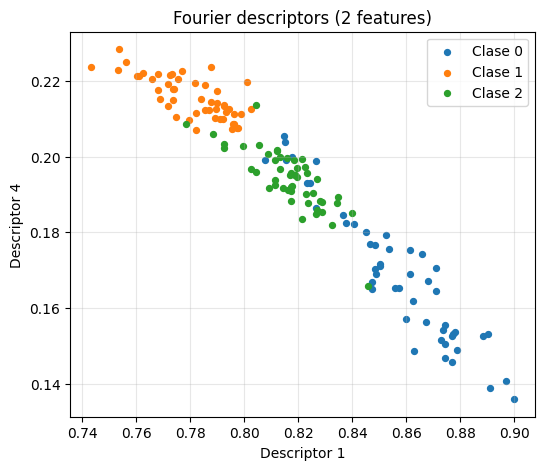

In [ ]:
# OJO: índices en Python empiezan en 0
descriptor_1 = 0  # 1er descriptor
descriptor_4 = 3  # 4to descriptor

X_selected = X[:, [descriptor_1, descriptor_4]]

plt.figure(figsize=(6,5))
for c in np.unique(y):
    pts = X_selected[y == c]
    plt.scatter(pts[:,0], pts[:,1], label=f"Clase {c}", s=18)

plt.title("Fourier descriptors (2 features)")
plt.xlabel(f"Descriptor {descriptor_1+1}")
plt.ylabel(f"Descriptor {descriptor_4+1}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import cv2

def imageload_from_path(path, echo=False):
    """
    Carga imagen desde Drive en GRIS normalizada [0,1].
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = img.astype(np.float32) / 255.0
    if echo:
        print("Loaded:", path, "| shape:", img.shape)
    return img

def segmentar_objeto(img01):
    """
    Segmentación automática:
    - blur
    - Otsu
    - invertir si quedó al revés
    - morfología para limpiar
    Devuelve máscara binaria (0/255).
    """
    gris = (img01 * 255).astype(np.uint8)
    blur = cv2.GaussianBlur(gris, (5, 5), 0)
    _, binaria = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Si el fondo quedó blanco y el objeto negro, invertimos
    if np.mean(binaria) > 127:
        binaria = cv2.bitwise_not(binaria)

    kernel = np.ones((5, 5), np.uint8)
    binaria = cv2.morphologyEx(binaria, cv2.MORPH_CLOSE, kernel, iterations=2)
    binaria = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, kernel, iterations=1)
    return binaria

def contorno_principal(mask):
    """
    Encuentra el contorno más grande (objeto).
    Devuelve Nx2 (x,y) o None si falla.
    """
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(c) < 80:  # muy pequeño = ruido
        return None
    return c.reshape(-1, 2)

In [ ]:
def re_muestrear_contorno(contorno_xy, n_puntos=256):
    """
    Re-muestrea el contorno a longitud fija n_puntos (para comparar imágenes).
    """
    pts = contorno_xy.astype(np.float32)

    dif = np.diff(pts, axis=0, append=pts[:1])
    dist = np.sqrt((dif**2).sum(axis=1))
    s = np.cumsum(dist)
    s = np.insert(s, 0, 0.0)
    total = s[-1]
    if total == 0:
        return None

    s_target = np.linspace(0, total, n_puntos+1)[:-1]
    x = np.interp(s_target, s, np.r_[pts[:,0], pts[0,0]])
    y = np.interp(s_target, s, np.r_[pts[:,1], pts[0,1]])
    return np.stack([x, y], axis=1)

def fourierdes_contorno(contorno_xy, num_descriptors=16, n_puntos=256):
    """
    Fourier descriptors de FORMA:
    - re-muestreo del contorno
    - centrar (invariancia a traslación)
    - señal compleja z = x + j*y
    - FFT
    - tomar magnitudes de los primeros coeficientes (invariancia aprox. a rotación)
    - normalizar por el primero (invariancia a escala)
    """
    pts = re_muestrear_contorno(contorno_xy, n_puntos=n_puntos)
    if pts is None:
        return None

    pts = pts - pts.mean(axis=0, keepdims=True)   # traslación
    z = pts[:, 0] + 1j * pts[:, 1]
    Z = np.fft.fft(z)

    mag = np.abs(Z)  # magnitud ~ rotación-invariante
    if len(mag) < num_descriptors + 1:
        return None

    desc = mag[1:num_descriptors+1].astype(np.float32)  # saltamos DC
    desc = desc / (desc[0] + 1e-8)  # escala-invariante
    return desc

def normalize_desc(desc):
    """
    Normalización tipo notebook: desc / ||desc||
    """
    return desc / (np.linalg.norm(desc) + 1e-8)

In [ ]:
num_descriptors = 16  # como tu notebook

X = np.zeros((num_classes * num_images_per_class, num_descriptors), dtype=np.float32)
y = np.zeros((num_classes * num_images_per_class,), dtype=np.int32)

t = 0
fails = 0

for class_idx in range(num_classes):                 # for each class
    for image_idx in range(num_images_per_class):    # for each image in the class

        # Load the image
        path = listas_imagenes[class_idx][image_idx]
        loaded_image = imageload_from_path(path, echo=False)
        if loaded_image is None:
            fails += 1
            continue

        # Segmentation (binaria)
        segmented_mask = segmentar_objeto(loaded_image)

        # Contour (objeto)
        cont = contorno_principal(segmented_mask)
        if cont is None:
            fails += 1
            continue

        # Fourier descriptors (FORMA)
        fourier_descriptors = fourierdes_contorno(cont, num_descriptors=num_descriptors, n_puntos=256)
        if fourier_descriptors is None:
            fails += 1
            continue

        # Normalization
        normalized_descriptors = normalize_desc(fourier_descriptors)

        # Store
        X[t, :] = normalized_descriptors
        y[t] = class_idx
        t += 1

# recortar por si hubo fallos
X = X[:t, :]
y = y[:t]

print("✅ Listo")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Fallos:", fails)
print("Clases presentes:", np.unique(y))

✅ Listo
X shape: (150, 16)
y shape: (150,)
Fallos: 0
Clases presentes: [0 1 2]


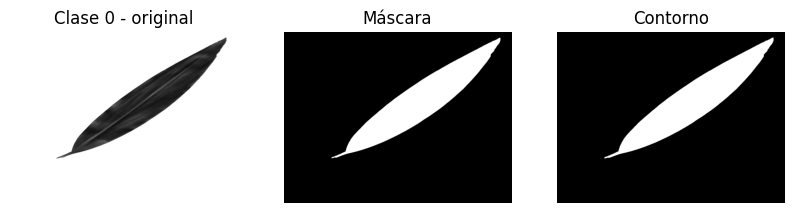

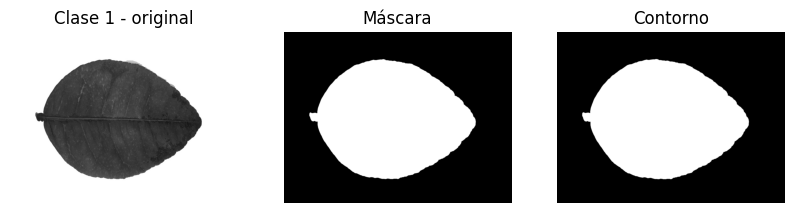

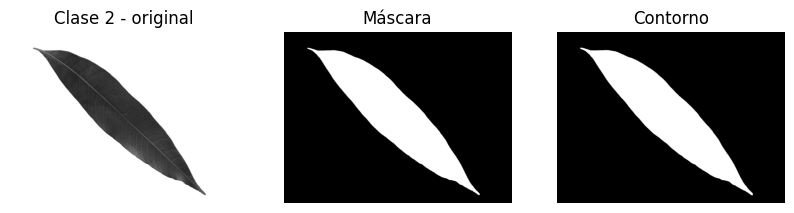

In [ ]:
import matplotlib.pyplot as plt

# mira un ejemplo de cada clase
for c in range(num_classes):
    path = listas_imagenes[c][0]
    img = imageload_from_path(path)
    mask = segmentar_objeto(img)
    cont = contorno_principal(mask)

    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    if cont is not None:
        cv2.drawContours(mask_rgb, [cont.reshape(-1,1,2)], -1, (255,255,255), 2)

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title(f"Clase {c} - original"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Máscara"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(mask_rgb); plt.title("Contorno"); plt.axis("off")
    plt.show()